# M2 — Fine-tuning CheXpert | Center Crop | U-Ignore
**Projeto Integrador SENAI FATESG 2025/2026**  
Domain Transfer: NIH → CheXpert | U-Ignore | Xception 512×512 | Com retomada de checkpoint

## SEÇÃO 0 — Setup e Instalações

In [ ]:
!pip install -q tensorflow keras scikit-learn matplotlib pandas numpy

In [ ]:
import os, json, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, optimizers, regularizers
from tensorflow.keras.applications import Xception

from google.colab import drive
drive.mount('/content/drive')

gpus = tf.config.list_physical_devices('GPU')
print(f'GPUs: {gpus}')
print(f'TensorFlow: {tf.__version__}')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

Mounted at /content/drive
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow: 2.20.0


In [ ]:
# ── Caminhos ──────────────────────────────────────────────────────────────────
BASE_DRIVE  = '/content/drive/MyDrive'
CHEX_DIR    = f'{BASE_DRIVE}/datasets_pi_2026/estruturacao/Stanford_Cropping'
TRAIN_CSV   = f'{CHEX_DIR}/chex_crop_train.csv'
VALID_CSV   = f'{CHEX_DIR}/chex_crop_valid.csv'

# Checkpoint M1 — ponto de partida do fine-tuning
M1_CKPT     = f'{BASE_DRIVE}/datasets_pi_2026/modelos/M1_NIH/checkpoints/m1_fase3_best.keras'

OUT_DIR     = f'{BASE_DRIVE}/datasets_pi_2026/modelos/M2_NIH_CheXpert_Crop_UIgnore'
CKPT_DIR    = f'{OUT_DIR}/checkpoints'
LOG_DIR     = f'{OUT_DIR}/logs'
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(LOG_DIR,  exist_ok=True)

# ── Labels ────────────────────────────────────────────────────────────────────
LABELS   = ['atelectasis','cardiomegaly','pleural_effusion',
            'pneumothorax','consolidation','edema']
N_LABELS = len(LABELS)

# ── Hiperparâmetros ───────────────────────────────────────────────────────────
IMG_SIZE   = 512
BATCH_SIZE = 32
EPOCHS_P1  = 20    # Fase 1 — frozen (backbone já adaptado ao CXR pelo M1)
EPOCHS_P2  = 40    # Fase 2 — unfreeze top 30%
EPOCHS_P3  = 30    # Fase 3 — unfreeze completo
LR_P1      = 1e-3
LR_P2      = 1e-4
LR_P3      = 1e-5
DROPOUT_1  = 0.5
DROPOUT_2  = 0.3
PATIENCE   = 7
VARIANT    = 'CROPPING'
PREFIX     = 'm2_crop'

print(f'Variant  : {VARIANT}')
print(f'M1 ckpt  : {M1_CKPT}')
print(f'Out dir  : {OUT_DIR}')
print(f'Epochs   : P1={EPOCHS_P1} | P2={EPOCHS_P2} | P3={EPOCHS_P3} | Total={EPOCHS_P1+EPOCHS_P2+EPOCHS_P3}')

Variant  : CROPPING
M1 ckpt  : /content/drive/MyDrive/datasets_pi_2026/modelos/M1_NIH/checkpoints/m1_fase3_best.keras
Out dir  : /content/drive/MyDrive/datasets_pi_2026/modelos/M2_NIH_CheXpert_Crop_UIgnore
Epochs   : P1=20 | P2=40 | P3=30 | Total=90


## SEÇÃO 1 — Carregamento e Validação dos CSVs

In [ ]:
df_train = pd.read_csv(TRAIN_CSV)
df_valid = pd.read_csv(VALID_CSV)

print('Path no CSV:')
print(df_train['img_path'].iloc[0])

print('\n Verifica existência:')
import os
p = df_train['img_path'].iloc[0]
print(f'  Existe: {os.path.exists(p)}')

# Verifica se o Drive está montado
print(f'\n  /content/drive existe: {os.path.exists("/content/drive")}')
print(f'  /content/drive/MyDrive existe: {os.path.exists("/content/drive/MyDrive")}')

# Lista o que tem na pasta esperada
expected_dir = f'{BASE_DRIVE}/datasets_pi_2026/estruturacao/Stanford_Cropping/images_512'
print(f'\n  Pasta de imagens existe: {os.path.exists(expected_dir)}')
if os.path.exists(expected_dir):
    files = os.listdir(expected_dir)[:3]
    print(f'  Primeiros arquivos: {files}')

Path no CSV:
/content/drive/MyDrive/datasets_pi_2026/estruturacao/Stanford_Cropping/images_512/CheXpert-v1.0_train_patient00001_study1_view1_frontal.png

 Verifica existência:
  Existe: True

  /content/drive existe: True
  /content/drive/MyDrive existe: True

  Pasta de imagens existe: True
  Primeiros arquivos: ['CheXpert-v1.0_train_patient00426_study22_view1_frontal.png', 'CheXpert-v1.0_train_patient00426_study41_view1_frontal.png', 'CheXpert-v1.0_train_patient00426_study19_view1_frontal.png']


In [ ]:
print('Verificando integridade de todos os paths do train...')
missing = []
for p in df_train['img_path']:
    if not os.path.exists(p):
        missing.append(p)

print(f'Total train    : {len(df_train):,}')
print(f'Paths válidos  : {len(df_train) - len(missing):,}')
print(f'Paths faltando : {len(missing):,}')
if missing[:5]:
    print('Exemplos:', [p.split("/")[-1] for p in missing[:5]])

Verificando integridade de todos os paths do train...
Total train    : 87,258
Paths válidos  : 87,258
Paths faltando : 0


In [ ]:
print(f'Train: {len(df_train):,} | Valid: {len(df_valid):,}')

# Valida paths
sample = df_train['img_path'].sample(5, random_state=42).tolist()
print('\nValidação de paths:')
for p in sample:
    print(f'  {"✅" if os.path.exists(p) else "❌"} {p.split("/")[-1]}')

# Distribuição por label (+1 confirmados e U-Ignore)
print('\nDistribuição train (U-Ignore — apenas +1 confirmados):')
for lbl in LABELS:
    n_pos = (df_train[f'{lbl}_uignore'] == 1).sum()
    n_nan = df_train[f'{lbl}_uignore'].isna().sum()
    n_neg = (df_train[f'{lbl}_uignore'] == 0).sum()
    print(f'  {lbl:<20}: +1={n_pos:>7,} | 0={n_neg:>7,} | ignorados={n_nan:>7,}')

Train: 87,258 | Valid: 159

Validação de paths:
  ✅ CheXpert-v1.0_train_patient15426_study40_view1_frontal.png
  ✅ CheXpert-v1.0_train_patient06871_study2_view1_frontal.png
  ✅ CheXpert-v1.0_train_patient32844_study1_view1_frontal.png
  ✅ CheXpert-v1.0_train_patient10968_study5_view1_frontal.png
  ✅ CheXpert-v1.0_train_patient31405_study1_view1_frontal.png

Distribuição train (U-Ignore — apenas +1 confirmados):
  atelectasis         : +1= 19,865 | 0=    500 | ignorados= 66,893
  cardiomegaly        : +1= 17,504 | 0=  3,203 | ignorados= 66,551
  pleural_effusion    : +1= 37,752 | 0= 11,077 | ignorados= 38,429
  pneumothorax        : +1= 15,410 | 0= 19,390 | ignorados= 52,458
  consolidation       : +1= 12,983 | 0=  8,159 | ignorados= 66,116
  edema               : +1= 27,102 | 0=  6,967 | ignorados= 53,189


## SEÇÃO 2 — Dataset Pipeline com U-Ignore

In [ ]:
# ── Colunas U-Ignore ──────────────────────────────────────────────────────────
LABEL_COLS = [f'{lbl}_uignore' for lbl in LABELS]

def load_image_chex(img_path, label, mask, training=False):
    """
    label: valores 0/1 com NaN→0
    mask : 1.0=válido, 0.0=era NaN (será ignorado na loss)
    """
    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=1)
    img = tf.cast(img, tf.float32) / 255.0
    img = (img - 0.5056) / 0.2520
    img = tf.repeat(img, 3, axis=-1)
    img = tf.ensure_shape(img, [IMG_SIZE, IMG_SIZE, 3])
    if training:
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, max_delta=0.1)
        img = tf.image.random_contrast(img, lower=0.9, upper=1.1)
    # Concatena label + mask para a FocalLossUIgnore
    label_mask = tf.concat([label, mask], axis=0)
    return img, label_mask

def make_dataset_chex(df, label_cols, training=False, batch_size=BATCH_SIZE):
    paths     = df['img_path'].values
    label_arr = df[label_cols].values.astype(np.float32)
    mask_arr  = (~df[label_cols].isna()).values.astype(np.float32)
    label_arr = np.nan_to_num(label_arr, nan=0.0)
    # Concatena label e mask — shape (N, N_LABELS*2)
    label_mask = np.concatenate([label_arr, mask_arr], axis=1)

    ds = tf.data.Dataset.from_tensor_slices((paths, label_mask))
    ds = ds.map(lambda p, lm: load_image_chex(
                    p,
                    lm[:N_LABELS],
                    lm[N_LABELS:],
                    training=training),
                num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.shuffle(buffer_size=4096, seed=SEED)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

print('Criando datasets...')
ds_train = make_dataset_chex(df_train, LABEL_COLS, training=True)
ds_valid = make_dataset_chex(df_valid, LABEL_COLS, training=False)
print(f'Train batches: {len(ds_train):,} | Valid batches: {len(ds_valid):,}')

for imgs, lm in ds_train.take(1):
    print(f'Batch shape      : {imgs.shape}')
    print(f'Label+mask shape : {lm.shape}  (primeiros {N_LABELS}=labels, últimos {N_LABELS}=mask)')
    print(f'Pixel range      : [{imgs.numpy().min():.3f}, {imgs.numpy().max():.3f}]')
    mask_coverage = lm[:, N_LABELS:].numpy().mean()
    print(f'Mask coverage    : {mask_coverage:.3f} (fração de labels válidos por batch)')
    break

Criando datasets...
Train batches: 2,727 | Valid batches: 5
Batch shape      : (32, 512, 512, 3)
Label+mask shape : (32, 12)  (primeiros 6=labels, últimos 6=mask)
Pixel range      : [-2.148, 2.100]
Mask coverage    : 0.370 (fração de labels válidos por batch)


## SEÇÃO 3 — Focal Loss U-Ignore e MacroAUROC

In [ ]:
class FocalLossUIgnore(tf.keras.losses.Loss):
    """
    Focal Loss com máscara U-Ignore.
    y_true shape: (batch, N_LABELS*2) — [:N_LABELS]=labels, [N_LABELS:]=mask
    Contribuição de labels com NaN é zerada pela máscara.
    """
    def __init__(self, gamma=2.0, alpha=0.25, label_weights=None, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma
        self.alpha = alpha
        self.label_weights = (tf.constant(label_weights, dtype=tf.float32)
                              if label_weights is not None
                              else tf.ones(N_LABELS, dtype=tf.float32))

    def call(self, y_true, y_pred):
        labels = y_true[:, :N_LABELS]
        mask   = y_true[:, N_LABELS:]
        y_pred  = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        bce     = -(labels * tf.math.log(y_pred) +
                    (1 - labels) * tf.math.log(1 - y_pred))
        p_t     = labels * y_pred + (1 - labels) * (1 - y_pred)
        alpha_t = labels * self.alpha + (1 - labels) * (1 - self.alpha)
        focal   = alpha_t * tf.pow(1 - p_t, self.gamma) * bce * self.label_weights
        focal_masked = focal * mask
        n_valid = tf.reduce_sum(mask) + 1e-7
        return tf.reduce_sum(focal_masked) / n_valid

    def get_config(self):
        config = super().get_config()
        config.update({'gamma': self.gamma, 'alpha': self.alpha,
                       'label_weights': self.label_weights.numpy().tolist()})
        return config


class MacroAUROC(tf.keras.metrics.Metric):
    """Macro-AUROC — extrai só os labels (primeiros N_LABELS) do y_true concatenado."""
    def __init__(self, n_labels=N_LABELS, name='macro_auroc', **kwargs):
        super().__init__(name=name, **kwargs)
        self.n_labels = n_labels
        self.aucs = [tf.keras.metrics.AUC(curve='ROC', name=f'auc_{i}')
                     for i in range(n_labels)]

    def update_state(self, y_true, y_pred, sample_weight=None):
        labels = y_true[:, :self.n_labels]
        for i, auc in enumerate(self.aucs):
            auc.update_state(labels[:, i], y_pred[:, i], sample_weight)

    def result(self):
        return tf.reduce_mean([auc.result() for auc in self.aucs])

    def reset_state(self):
        for auc in self.aucs:
            auc.reset_state()

    def get_config(self):
        config = super().get_config()
        config.update({'n_labels': self.n_labels})
        return config


class MaskedBinaryAccuracy(tf.keras.metrics.Metric):
    """BinaryAccuracy que extrai só os labels (primeiros N_LABELS) do y_true concatenado."""
    def __init__(self, n_labels=N_LABELS, name='accuracy', **kwargs):
        super().__init__(name=name, **kwargs)
        self.n_labels = n_labels
        self.acc = tf.keras.metrics.BinaryAccuracy()

    def update_state(self, y_true, y_pred, sample_weight=None):
        labels = y_true[:, :self.n_labels]
        self.acc.update_state(labels, y_pred, sample_weight)

    def result(self):
        return self.acc.result()

    def reset_state(self):
        self.acc.reset_state()

    def get_config(self):
        config = super().get_config()
        config.update({'n_labels': self.n_labels})
        return config


# ── Label weights sobre +1 U-Ignore ──────────────────────────────────────────
N = len(df_train)
label_weights_focal = np.array([
    N / (N_LABELS * (df_train[f'{lbl}_uignore'] == 1).sum())
    if (df_train[f'{lbl}_uignore'] == 1).sum() > 0 else 1.0
    for lbl in LABELS
], dtype=np.float32)

print('Label weights Focal Loss (U-Ignore):')
for lbl, w in zip(LABELS, label_weights_focal):
    print(f'  {lbl:<20}: {w:.4f}')

CUSTOM_OBJECTS = {
    'FocalLossUIgnore'    : FocalLossUIgnore,
    'MacroAUROC'          : MacroAUROC,
    'MaskedBinaryAccuracy': MaskedBinaryAccuracy
}

Label weights Focal Loss (U-Ignore):
  atelectasis         : 0.7321
  cardiomegaly        : 0.8308
  pleural_effusion    : 0.3852
  pneumothorax        : 0.9437
  consolidation       : 1.1202
  edema               : 0.5366


## SEÇÃO 4 — Carrega Backbone M1 e Reconstrói Modelo

In [ ]:
def build_model_from_m1(m1_ckpt, trainable_backbone=False):
    """
    Carrega o modelo M1 completo e o usa como ponto de partida.
    A arquitetura é idêntica ao M1 — mesma cabeça, mesma saída (N_LABELS, sigmoid).
    Só muda o dataset de fine-tuning e a loss function.
    """
    if not os.path.exists(m1_ckpt):
        raise FileNotFoundError(f'Checkpoint M1 não encontrado: {m1_ckpt}')

    # Carrega M1 com suas classes customizadas
    m1_custom = {
        'FocalLoss': type('FocalLoss', (tf.keras.losses.Loss,), {}),
        'MacroAUROC': type('MacroAUROC', (tf.keras.metrics.Metric,), {})
    }
    try:
        model = tf.keras.models.load_model(m1_ckpt, compile=False)
    except Exception:
        # Fallback se classes não forem encontradas
        model = tf.keras.models.load_model(m1_ckpt, compile=False,
                                           custom_objects=m1_custom)

    # Congela ou descongela backbone
    for layer in model.layers:
        layer.trainable = not trainable_backbone if trainable_backbone is False else True

    if not trainable_backbone:
        # Congela tudo exceto a cabeça (últimas camadas Dense)
        for layer in model.layers:
            layer.trainable = False
        # Descongela as camadas da cabeça
        head_layers = ['global_average_pooling2d', 'dense', 'batch_normalization', 'dropout', 'predictions']
        for layer in model.layers:
            for name in head_layers:
                if name in layer.name:
                    layer.trainable = True
                    break

    return model

# Verifica existência do M1
print(f'M1 checkpoint: {M1_CKPT}')
print(f'Existe: {"✅" if os.path.exists(M1_CKPT) else "❌ NÃO ENCONTRADO"}')

# Teste de construção
model_test = build_model_from_m1(M1_CKPT, trainable_backbone=False)
total     = model_test.count_params()
trainable = sum([tf.size(w).numpy() for w in model_test.trainable_weights])
print(f'Total parâmetros    : {total:,}')
print(f'Treináveis (Fase 1) : {trainable:,}')
print(f'Congelados (Fase 1) : {total - trainable:,}')
del model_test

M1 checkpoint: /content/drive/MyDrive/datasets_pi_2026/modelos/M1_NIH/checkpoints/m1_fase3_best.keras
Existe: ✅
Total parâmetros    : 22,045,486
Treináveis (Fase 1) : 1,187,254
Congelados (Fase 1) : 20,858,232


## SEÇÃO 5 — Callbacks e Funções de Retomada

In [ ]:
def get_callbacks(phase, model_name):
    ckpt_path = f'{CKPT_DIR}/{model_name}_best.keras'
    cb_list = [
        callbacks.ModelCheckpoint(
            filepath=ckpt_path,
            monitor='val_macro_auroc',
            mode='max',
            save_best_only=True,
            verbose=1
        ),
        callbacks.EarlyStopping(
            monitor='val_macro_auroc',
            mode='max',
            patience=PATIENCE,
            restore_best_weights=True,
            verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_macro_auroc',
            mode='max',
            factor=0.5,
            patience=3,
            min_lr=1e-7,
            verbose=1
        ),
        callbacks.CSVLogger(
            f'{LOG_DIR}/{PREFIX}_fase{phase}_history.csv',
            append=True
        ),
        callbacks.TensorBoard(
            log_dir=f'{LOG_DIR}/fase{phase}',
            histogram_freq=0
        ),
    ]
    return cb_list, ckpt_path

def load_checkpoint(ckpt_path):
    if os.path.exists(ckpt_path):
        print(f'Checkpoint encontrado: {ckpt_path}')
        model = tf.keras.models.load_model(ckpt_path, custom_objects=CUSTOM_OBJECTS)
        return model, True
    print(f'Sem checkpoint em {ckpt_path} — iniciando do zero.')
    return None, False

def get_initial_epoch(phase):
    log_path = f'{LOG_DIR}/{PREFIX}_fase{phase}_history.csv'
    if os.path.exists(log_path):
        try:
            df_log = pd.read_csv(log_path)
            epochs_done = len(df_log)
            print(f'{epochs_done} epochs já concluídos nesta fase')
            return epochs_done
        except Exception:
            return 0
    return 0

print('Callbacks e funções de retomada definidos.')

Callbacks e funções de retomada definidos.


## SEÇÃO 6 — Fase 1: Frozen Backbone

In [ ]:
print('='*60)
print(f'FASE 1 — Frozen backbone | LR={LR_P1} | Epochs={EPOCHS_P1}')
print('='*60)

CKPT_P1 = f'{CKPT_DIR}/{PREFIX}_fase1_best.keras'
cb_p1, _ = get_callbacks(phase=1, model_name=f'{PREFIX}_fase1')
initial_epoch_p1 = get_initial_epoch(phase=1)

model_p1, loaded = load_checkpoint(CKPT_P1)
if not loaded:
    model_p1 = build_model_from_m1(M1_CKPT, trainable_backbone=False)

model_p1.compile(
    optimizer=optimizers.Adam(learning_rate=LR_P1),
    loss=FocalLossUIgnore(gamma=2.0, alpha=0.25, label_weights=label_weights_focal),
    metrics=[MacroAUROC(name='macro_auroc'),
             MaskedBinaryAccuracy(name='accuracy')]
)

trainable_p1 = sum([tf.size(w).numpy() for w in model_p1.trainable_weights])
print(f'Treináveis Fase 1: {trainable_p1:,}')
print(f'Iniciando do epoch: {initial_epoch_p1 + 1}')

if initial_epoch_p1 >= EPOCHS_P1:
    print('Fase 1 já concluída — pulando para Fase 2.')
else:
    history_p1 = model_p1.fit(
        ds_train,
        validation_data=ds_valid,
        epochs=EPOCHS_P1,
        initial_epoch=initial_epoch_p1,
        callbacks=cb_p1,
        verbose=1
    )
    print(f'\n Fase 1 concluída. Melhor val_macro_auroc: {max(history_p1.history["val_macro_auroc"]):.4f}')

FASE 1 — Frozen backbone | LR=0.001 | Epochs=20
20 epochs já concluídos nesta fase
Checkpoint encontrado: /content/drive/MyDrive/datasets_pi_2026/modelos/M2_NIH_CheXpert_Crop_UIgnore/checkpoints/m2_crop_fase1_best.keras
Treináveis Fase 1: 1,187,254
Iniciando do epoch: 21
Fase 1 já concluída — pulando para Fase 2.


## SEÇÃO 7 — Fase 2: Unfreeze Top 30%

In [ ]:
print('='*60)
print(f'FASE 2 — Unfreeze top 30% | LR={LR_P2} | Epochs={EPOCHS_P2}')
print('='*60)

CKPT_P2 = f'{CKPT_DIR}/{PREFIX}_fase2_best.keras'
cb_p2, _ = get_callbacks(phase=2, model_name=f'{PREFIX}_fase2')
initial_epoch_p2 = get_initial_epoch(phase=2)

model_p2, loaded = load_checkpoint(CKPT_P2)
if not loaded:
    model_p2, loaded_p1 = load_checkpoint(CKPT_P1)
    if not loaded_p1:
        raise RuntimeError('Checkpoint da Fase 1 não encontrado. Execute a Fase 1 primeiro.')

    all_layers    = model_p2.layers
    n_total       = len(all_layers)
    n_unfreeze    = int(n_total * 0.30)
    unfreeze_from = n_total - n_unfreeze
    print(f'Total de camadas: {n_total}')
    print(f'Descongelando as últimas {n_unfreeze} (índice {unfreeze_from} em diante)')
    for i, layer in enumerate(all_layers):
        layer.trainable = (i >= unfreeze_from)
    for layer in all_layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False
else:
    all_layers    = model_p2.layers
    n_total       = len(all_layers)
    n_unfreeze    = int(n_total * 0.30)
    unfreeze_from = n_total - n_unfreeze
    for i, layer in enumerate(all_layers):
        layer.trainable = (i >= unfreeze_from)
    for layer in all_layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

model_p2.compile(
    optimizer=optimizers.Adam(learning_rate=LR_P2),
    loss=FocalLossUIgnore(gamma=2.0, alpha=0.25, label_weights=label_weights_focal),
    metrics=[MacroAUROC(name='macro_auroc'),
             MaskedBinaryAccuracy(name='accuracy')]
)

trainable_p2 = sum([tf.size(w).numpy() for w in model_p2.trainable_weights])
print(f'Treináveis Fase 2: {trainable_p2:,}')
print(f'Iniciando do epoch: {initial_epoch_p2 + 1}')

if initial_epoch_p2 >= EPOCHS_P2:
    print('Fase 2 já concluída — pulando para Fase 3.')
else:
    history_p2 = model_p2.fit(
        ds_train,
        validation_data=ds_valid,
        epochs=EPOCHS_P2,
        initial_epoch=initial_epoch_p2,
        callbacks=cb_p2,
        verbose=1
    )
    print(f'\n Fase 2 concluída. Melhor val_macro_auroc: {max(history_p2.history["val_macro_auroc"]):.4f}')

FASE 2 — Unfreeze top 30% | LR=0.0001 | Epochs=40
9 epochs já concluídos nesta fase
Checkpoint encontrado: /content/drive/MyDrive/datasets_pi_2026/modelos/M2_NIH_CheXpert_Crop_UIgnore/checkpoints/m2_crop_fase2_best.keras
Treináveis Fase 2: 10,640,302
Iniciando do epoch: 10
Epoch 10/40
2727/2727 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5829 - loss: 0.0236 - macro_auroc: 0.7487
Epoch 10: val_macro_auroc improved from None to 0.85942, saving model to /content/drive/MyDrive/datasets_pi_2026/modelos/M2_NIH_CheXpert_Crop_UIgnore/checkpoints/m2_crop_fase2_best.keras

Epoch 10: finished saving model to /content/drive/MyDrive/datasets_pi_2026/modelos/M2_NIH_CheXpert_Crop_UIgnore/checkpoints/m2_crop_fase2_best.keras
2727/2727 ━━━━━━━━━━━━━━━━━━━━ 6295s 2s/step - accuracy: 0.5771 - loss: 0.0236 - macro_auroc: 0.7416 - val_accuracy: 0.7055 - val_loss: 0.0873 - val_macro_auroc: 0.8594 - learning_rate: 1.0000e-04
Epoch 11/40
2727/2727 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 0.5866 - loss

## SEÇÃO 8 — Fase 3: Unfreeze Completo

In [ ]:
print('='*60)
print(f'FASE 3 — Unfreeze completo | LR={LR_P3} | Epochs={EPOCHS_P3}')
print('='*60)

CKPT_P3 = f'{CKPT_DIR}/{PREFIX}_fase3_best.keras'
cb_p3, _ = get_callbacks(phase=3, model_name=f'{PREFIX}_fase3')
initial_epoch_p3 = get_initial_epoch(phase=3)

model_p3, loaded = load_checkpoint(CKPT_P3)
if not loaded:
    model_p3, loaded_p2 = load_checkpoint(CKPT_P2)
    if not loaded_p2:
        raise RuntimeError('Checkpoint da Fase 2 não encontrado. Execute a Fase 2 primeiro.')
    for layer in model_p3.layers:
        layer.trainable = True
    for layer in model_p3.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False
else:
    for layer in model_p3.layers:
        layer.trainable = True
    for layer in model_p3.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

model_p3.compile(
    optimizer=optimizers.Adam(learning_rate=LR_P3),
    loss=FocalLossUIgnore(gamma=2.0, alpha=0.25, label_weights=label_weights_focal),
    metrics=[MacroAUROC(name='macro_auroc'),
             MaskedBinaryAccuracy(name='accuracy')]
)

trainable_p3 = sum([tf.size(w).numpy() for w in model_p3.trainable_weights])
print(f'Treináveis Fase 3: {trainable_p3:,}')
print(f'Iniciando do epoch: {initial_epoch_p3 + 1}')

if initial_epoch_p3 >= EPOCHS_P3:
    print('Fase 3 já concluída — indo para avaliação final.')
else:
    history_p3 = model_p3.fit(
        ds_train,
        validation_data=ds_valid,
        epochs=EPOCHS_P3,
        initial_epoch=initial_epoch_p3,
        callbacks=cb_p3,
        verbose=1
    )
    print(f'\n Fase 3 concluída. Melhor val_macro_auroc: {max(history_p3.history["val_macro_auroc"]):.4f}')

FASE 3 — Unfreeze completo | LR=1e-05 | Epochs=30
11 epochs já concluídos nesta fase
Checkpoint encontrado: /content/drive/MyDrive/datasets_pi_2026/modelos/M2_NIH_CheXpert_Crop_UIgnore/checkpoints/m2_crop_fase3_best.keras
Treináveis Fase 3: 21,934,382
Iniciando do epoch: 12
Epoch 12/30
2727/2727 ━━━━━━━━━━━━━━━━━━━━ 0s 806ms/step - accuracy: 0.5928 - loss: 0.0176 - macro_auroc: 0.7692
Epoch 12: val_macro_auroc improved from None to 0.87056, saving model to /content/drive/MyDrive/datasets_pi_2026/modelos/M2_NIH_CheXpert_Crop_UIgnore/checkpoints/m2_crop_fase3_best.keras

Epoch 12: finished saving model to /content/drive/MyDrive/datasets_pi_2026/modelos/M2_NIH_CheXpert_Crop_UIgnore/checkpoints/m2_crop_fase3_best.keras
2727/2727 ━━━━━━━━━━━━━━━━━━━━ 2280s 811ms/step - accuracy: 0.5869 - loss: 0.0177 - macro_auroc: 0.7627 - val_accuracy: 0.7075 - val_loss: 0.1017 - val_macro_auroc: 0.8706 - learning_rate: 1.0000e-05
Epoch 13/30
2727/2727 ━━━━━━━━━━━━━━━━━━━━ 0s 793ms/step - accuracy: 0.5940

## SEÇÃO 9 — Avaliação Final

In [ ]:
print('='*60)
print('AVALIAÇÃO FINAL — M2 CheXpert Center Crop U-Ignore')
print('='*60)

# Garante que variáveis de caminho estão definidas em nova sessão
CKPT_P3 = f'{CKPT_DIR}/{PREFIX}_fase3_best.keras'

best_model = tf.keras.models.load_model(CKPT_P3, custom_objects=CUSTOM_OBJECTS)

print('Gerando predições no valid set...')
y_pred_raw = best_model.predict(ds_valid, verbose=1)
y_true = df_valid[LABELS].values.astype(np.float32)

print('\n' + '='*40)
print(f'  {"Label":<22} {"AUROC":>8}')
print('-'*32)
aurocs    = []
per_label = {}
for i, lbl in enumerate(LABELS):
    if len(np.unique(y_true[:, i])) > 1:
        auc = roc_auc_score(y_true[:, i], y_pred_raw[:, i])
        aurocs.append(auc)
        per_label[lbl] = float(auc)
        print(f'  {lbl:<22} {auc:.4f}')
    else:
        print(f'  {lbl:<22} {"N/A":>8}')

macro_auroc = float(np.mean(aurocs))
print('-'*32)
print(f'  {"Macro-AUROC":<22} {macro_auroc:.4f}')
print('='*40)
print(f'  Target 0.85–0.92 : {"Atingido" if macro_auroc >= 0.85 else "Abaixo do target"}')

results = {
    'model'          : 'M2_Crop_UIgnore',
    'variant'        : 'CROPPING',
    'policy'         : 'U-Ignore',
    'macro_auroc'    : macro_auroc,
    'epochs'         : {'p1': EPOCHS_P1, 'p2': EPOCHS_P2, 'p3': EPOCHS_P3},
    'per_label_auroc': per_label
}
with open(f'{OUT_DIR}/m2_crop_results.json', 'w') as f:
    json.dump(results, f, indent=2)
print(f'\nResultados salvos: {OUT_DIR}/m2_crop_results.json')

AVALIAÇÃO FINAL — M2 CheXpert Center Crop U-Ignore
Gerando predições no valid set...
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step

  Label                     AUROC
--------------------------------
  atelectasis            0.8103
  cardiomegaly           0.8254
  pleural_effusion       0.8775
  pneumothorax           0.9248
  consolidation          0.8932
  edema                  0.8948
--------------------------------
  Macro-AUROC            0.8710
  Target 0.85–0.92 : Atingido

Resultados salvos: /content/drive/MyDrive/datasets_pi_2026/modelos/M2_NIH_CheXpert_Crop_UIgnore/m2_crop_results.json


## SEÇÃO 10 — Curvas de Treino

/tmp/ipykernel_2280/1274816089.py:70: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax4.legend()


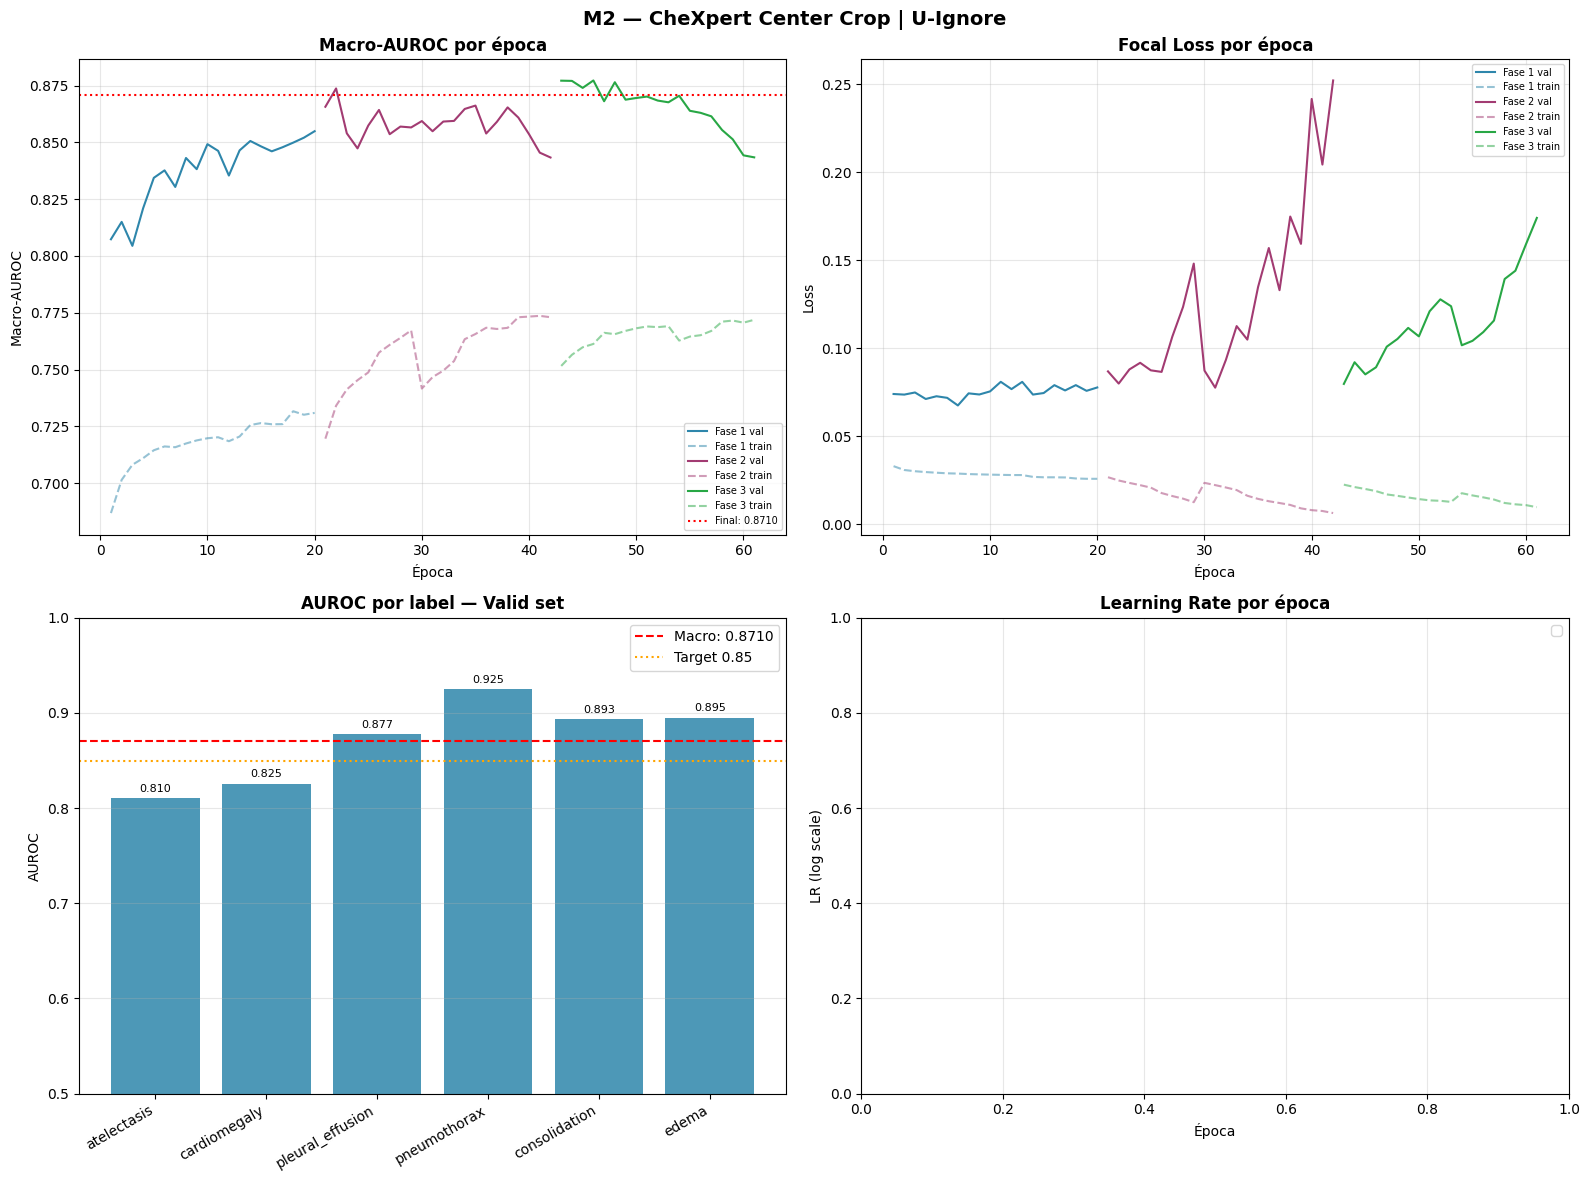

Curvas salvas.


In [ ]:
def load_history(phase):
    log_path = f'{LOG_DIR}/{PREFIX}_fase{phase}_history.csv'
    if os.path.exists(log_path):
        return pd.read_csv(log_path)
    return None

hist_p1 = load_history(1)
hist_p2 = load_history(2)
hist_p3 = load_history(3)

if 'macro_auroc' not in dir() or 'per_label' not in dir():
    with open(f'{OUT_DIR}/m2_crop_results.json') as f:
        res = json.load(f)
    macro_auroc = res['macro_auroc']
    per_label   = res['per_label_auroc']
    print('Resultados carregados do JSON.')

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'M2 — CheXpert Center Crop | U-Ignore', fontsize=14, fontweight='bold')
colors = {'Fase 1': '#2E86AB', 'Fase 2': '#A23B72', 'Fase 3': '#28A745'}

def plot_metric(ax, metric, val_metric, title, ylabel):
    offset = 0
    for fase, hist in [('Fase 1', hist_p1), ('Fase 2', hist_p2), ('Fase 3', hist_p3)]:
        if hist is None:
            continue
        epochs = range(offset + 1, offset + len(hist) + 1)
        ax.plot(epochs, hist[val_metric], label=f'{fase} val', color=colors[fase])
        if metric in hist.columns:
            ax.plot(epochs, hist[metric], label=f'{fase} train',
                    color=colors[fase], linestyle='--', alpha=0.5)
        offset += len(hist)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Época')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plot_metric(axes[0,0], 'macro_auroc', 'val_macro_auroc', 'Macro-AUROC por época', 'Macro-AUROC')
axes[0,0].axhline(y=macro_auroc, color='red', linestyle=':', label=f'Final: {macro_auroc:.4f}')
axes[0,0].legend(fontsize=7)

plot_metric(axes[0,1], 'loss', 'val_loss', 'Focal Loss por época', 'Loss')

ax3 = axes[1,0]
bars = ax3.bar(per_label.keys(), per_label.values(), color='#2E86AB', alpha=0.85)
ax3.axhline(y=macro_auroc, color='red', linestyle='--', label=f'Macro: {macro_auroc:.4f}')
ax3.axhline(y=0.85, color='orange', linestyle=':', label='Target 0.85')
ax3.set_title('AUROC por label — Valid set', fontweight='bold')
ax3.set_ylabel('AUROC')
ax3.set_ylim(0.5, 1.0)
ax3.legend()
ax3.grid(axis='y', alpha=0.3)
plt.sca(ax3); plt.xticks(rotation=30, ha='right')
for bar, val in zip(bars, per_label.values()):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax4 = axes[1,1]
offset = 0
for fase, hist in [('Fase 1', hist_p1), ('Fase 2', hist_p2), ('Fase 3', hist_p3)]:
    if hist is None or 'lr' not in hist.columns:
        continue
    epochs = range(offset + 1, offset + len(hist) + 1)
    ax4.semilogy(epochs, hist['lr'], label=fase, color=colors[fase])
    offset += len(hist)
ax4.set_title('Learning Rate por época', fontweight='bold')
ax4.set_xlabel('Época')
ax4.set_ylabel('LR (log scale)')
ax4.legend()
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/m2_crop_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Curvas salvas.')

In [ ]:
# ── Salva modelo final ────────────────────────────────────────────────────────
if 'best_model' not in dir():
    CKPT_P3 = f'{CKPT_DIR}/{PREFIX}_fase3_best.keras'
    best_model = tf.keras.models.load_model(CKPT_P3, custom_objects=CUSTOM_OBJECTS)
    print('Modelo carregado do checkpoint P3.')

if 'macro_auroc' not in dir():
    with open(f'{OUT_DIR}/m2_crop_results.json') as f:
        res = json.load(f)
    macro_auroc = res['macro_auroc']

final_path = f'{OUT_DIR}/m2_crop_final.keras'
best_model.save(final_path)
print(f'Modelo final salvo: {final_path}')
print(f'\n{"="*55}')
print(f'M2 Center Crop U-Ignore — RESUMO FINAL')
print(f'{"="*55}')
print(f'  Macro-AUROC : {macro_auroc:.4f}')
print(f'  Target      : 0.85–0.92')
print(f'  Status      : {"Atingido" if macro_auroc >= 0.85 else "Abaixo do target"}')
print(f'  Modelo      : {final_path}')
print(f'{"="*55}')

Modelo final salvo: /content/drive/MyDrive/datasets_pi_2026/modelos/M2_NIH_CheXpert_Crop_UIgnore/m2_crop_final.keras

M2 Center Crop U-Ignore — RESUMO FINAL
  Macro-AUROC : 0.8710
  Target      : 0.85–0.92
  Status      : Atingido
  Modelo      : /content/drive/MyDrive/datasets_pi_2026/modelos/M2_NIH_CheXpert_Crop_UIgnore/m2_crop_final.keras


## SEÇÃO 11 — Relatório

In [ ]:
# ── SEÇÃO 11 — Relatório Automático via Claude API ────────────────────────────
!pip install -q anthropic

import anthropic
import time

API_KEY = '<API_KEY>'
client  = anthropic.Anthropic(api_key=API_KEY)

if 'macro_auroc' not in dir() or 'per_label' not in dir():
    with open(f'{OUT_DIR}/m2_crop_results.json') as f:
        res = json.load(f)
    macro_auroc = res['macro_auroc']
    per_label   = res['per_label_auroc']

def load_history(phase):
    log_path = f'{LOG_DIR}/{PREFIX}_fase{phase}_history.csv'
    if os.path.exists(log_path):
        return pd.read_csv(log_path)
    return None

hist_p1 = load_history(1)
hist_p2 = load_history(2)
hist_p3 = load_history(3)

def hist_summary(hist, phase):
    if hist is None:
        return f'Fase {phase}: sem dados'
    best_val = hist['val_macro_auroc'].max()
    best_ep  = hist['val_macro_auroc'].idxmax() + 1
    last_lr  = float(hist['lr'].iloc[-1]) if 'lr' in hist.columns else None
    lr_str   = f'{last_lr:.2e}' if last_lr is not None else 'N/A'
    return (f'Fase {phase}: {len(hist)} epochs | '
            f'Melhor val_macro_auroc={best_val:.4f} (epoch {best_ep}) | '
            f'LR final={lr_str}')

label_lines = '\n'.join([
    f'  {lbl:<22}: {auc:.4f}' for lbl, auc in per_label.items()
])

# Carrega M1 para comparação
m1_macro = None
try:
    with open(f'{BASE_DRIVE}/datasets_pi_2026/modelos/M1_NIH/m1_results.json') as f:
        m1_res = json.load(f)
    m1_macro = m1_res['macro_auroc']
    m1_per_label = m1_res['per_label_auroc']
    m1_label_lines = '\n'.join([
        f'  {lbl:<22}: {m1_per_label.get(lbl, 0):.4f} → {per_label.get(lbl, 0):.4f} '
        f'({per_label.get(lbl,0)-m1_per_label.get(lbl,0):+.4f})'
        for lbl in per_label.keys()
    ])
except Exception:
    m1_label_lines = 'M1 results não disponíveis para comparação'
    m1_macro = None

context = f"""
MODELO: M2 — Xception 512×512 | Fine-tuning NIH→CheXpert | Center Crop | U-Ignore
OBJETIVO: Domain Transfer — mede impacto do pré-treino NIH sobre CheXpert

CONFIGURAÇÃO:
  Backbone      : Xception (pesos M1/NIH como ponto de partida)
  Preprocessing : Center Crop 2320×2320 → 512×512 PNG
  Política -1   : U-Ignore — labels incertos descartados da loss
  Input         : 512×512×3 (grayscale replicado)
  Cabeça        : GAP → Dense(512)+BN+Drop(0.5) → Dense(256)+Drop(0.3) → Dense(6,sigmoid)
  Loss          : Focal Loss U-Ignore γ=2.0 α=0.25 + pesos por label
  Early stopping: val_macro_auroc patience=7
  Scheduler     : ReduceLROnPlateau factor=0.5 patience=3

DATASET (Stanford CheXpert — Center Crop):
  Train: 87.258 imagens (undersample ~14.800/label)
  Valid: 159 imagens
  Labels: atelectasis, cardiomegaly, pleural_effusion, pneumothorax, consolidation, edema

ESTRATÉGIA DE TREINO:
  {hist_summary(hist_p1, 1)}
  {hist_summary(hist_p2, 2)}
  {hist_summary(hist_p3, 3)}

RESULTADOS NO VALID SET (M1→M2 comparação por label):
{m1_label_lines}
  {'─'*40}
  M1 Macro-AUROC (NIH)        : {f'{m1_macro:.4f}' if m1_macro else 'N/A'}
  M2 Macro-AUROC (CheXpert)   : {macro_auroc:.4f}
  Delta M1→M2                 : {f'{macro_auroc - m1_macro:+.4f}' if m1_macro else 'N/A'}
  Target                      : 0.85–0.92
  Status                      : {'Atingido' if macro_auroc >= 0.85 else 'Abaixo do target'}
"""

prompt = f"""Você é um pesquisador sênior em visão computacional médica.

Abaixo estão os resultados do modelo M2 — fine-tuning NIH→CheXpert com Center Crop e política U-Ignore, parte do ablation study de classificação multi-label de radiografias de tórax.

{context}

Produza um relatório técnico estruturado cobrindo:

1. **Resumo executivo**: resultado principal e delta M1→M2
2. **Impacto do Domain Transfer**: o fine-tuning no CheXpert melhorou o modelo em relação ao M1? Quais labels mais ganharam e por quê — relacionar com os shifts de prevalência NIH→CheXpert (Edema +21%, Pleural Effusion +26%, Cardiomegaly +9%)
3. **Análise por label**: labels que surpreenderam (positiva ou negativamente) e hipóteses
4. **Comportamento do treino**: análise das 3 fases, overfitting, resposta ao scheduler
5. **Impacto do Center Crop vs Zero Padding**: o que esperar de diferente quando o M2 Padding for comparado
6. **Impacto do U-Ignore**: como a política de descartar -1 afetou os resultados — especialmente Consolidation (27.742 incertos) e Atelectasis (33.739 incertos)
7. **Expectativa para M3 (U-Ones)**: quais labels devem mais mudar com a política U-Ones
8. **Pontos de atenção**: riscos e recomendações

Seja direto e técnico. Cite os números. Responda em português brasileiro."""

print('Enviando para Claude API...')
t0 = time.time()

message = client.messages.create(
    model='claude-sonnet-4-6',
    max_tokens=8192,
    messages=[{'role': 'user', 'content': prompt}]
)

relatorio = message.content[0].text
elapsed   = time.time() - t0
print(f'Resposta em {elapsed:.1f}s | {message.usage.input_tokens} in | {message.usage.output_tokens} out')

print('\n' + '='*65)
print('RELATÓRIO M2 CROP — Claude Sonnet')
print('='*65)
print(relatorio)

report_path = f'{OUT_DIR}/m2_crop_relatorio_claude.txt'
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(context + '\n\n' + '='*65 + '\nRELATÓRIO CLAUDE\n' + '='*65 + '\n\n' + relatorio)
print(f'\nRelatório salvo: {report_path}')